# Conditional DCGAN (cGAN)
### Butterfly Dataset — 75-class conditional image generation

Follows the GAN.py example pattern from `exemplos_modelos/` very closely:
- Same variable names: `netG`, `netD`, `optimizerG`, `optimizerD`, `criterion`
- Same Adam settings: `lr=0.0002, betas=(0.5, 0.999)`
- Same training loop structure and per-batch print format
- Same `real_label / fake_label` convention (with label smoothing: real=0.9)

Extension over the example: **class conditioning** via `nn.Embedding` injected into
both Generator (noise concatenation) and Discriminator (spatial projection).


In [1]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from torch.nn.utils import spectral_norm

# ── Device setup (following exemplos_modelos pattern) ──────────────────────
device = torch.device(
    "cuda"  if torch.cuda.is_available()  else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [2]:
sys.path.insert(0, os.path.abspath(".."))

from src.dataset import (
    ButterflyDataset, get_splits, build_label_map,
    get_train_transform, get_eval_transform, make_dataloader,
)
from src.utils import (
    save_checkpoint, load_checkpoint,
    visualize_grid, plot_losses,
    EarlyStopping, tensor_to_pil, denormalize,
)
from src.metrics import compute_fid, compute_inception_score

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath("..")
IMG_DIR     = os.path.join(BASE_DIR, "aca-butterflies", "train")
CSV_PATH    = os.path.join(BASE_DIR, "aca-butterflies", "train.csv")
SAVE_DIR    = os.path.join(BASE_DIR, "data", "generated", "gan")
NETG_PATH   = os.path.join(BASE_DIR, "saved_models", "gan_generator.pth")
NETD_PATH   = os.path.join(BASE_DIR, "saved_models", "gan_discriminator.pth")
os.makedirs(SAVE_DIR, exist_ok=True)

# Hyperparameters — mirroring GAN.py where applicable
IMAGE_SIZE  = 64        # matches TP2-students.ipynb
BATCH_SIZE  = 64        # RTX 5060 Laptop 8.5 GB VRAM
LATENT_DIM  = 100       # same as GAN.py noise dim
NUM_CLASSES = 75
EMB_DIM     = 100       # class embedding fed into G; projected to spatial in D

LR          = 0.0002    # from GAN.py
BETAS       = (0.5, 0.999)  # from GAN.py
NUM_EPOCHS  = 200
SAVE_EVERY  = 20        # save checkpoint every N epochs
real_label  = 0.9       # label smoothing (GAN.py uses 1; smoothing helps stability)
fake_label  = 0.0

In [4]:
label_to_idx, idx_to_label = build_label_map(CSV_PATH)
num_classes = len(label_to_idx)

train_df, val_df, test_df = get_splits(CSV_PATH, train_ratio=0.70, val_ratio=0.15, seed=42)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

train_set    = ButterflyDataset(train_df, IMG_DIR, label_to_idx,
                                transform=get_train_transform(IMAGE_SIZE))
train_loader = make_dataloader(train_set, BATCH_SIZE, shuffle=True)
print(f"Batches: {len(train_loader)}")

Train: 3,606  Val: 745  Test: 848
Batches: 57


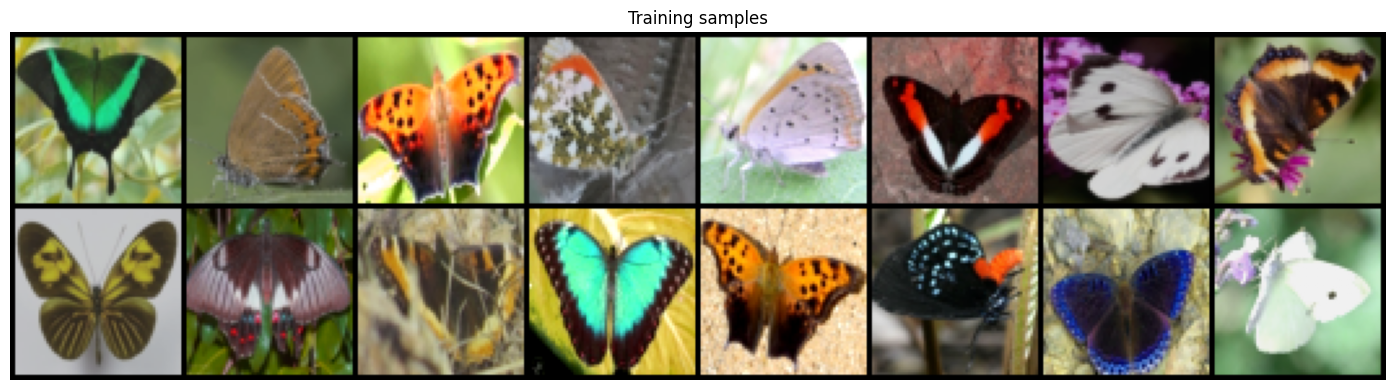

In [5]:
imgs, labs = next(iter(train_loader))
visualize_grid(imgs, labs, idx_to_label, n=16, nrow=8,
               title="Training samples", denorm=True)

## Model Architecture

### Generator (netG)
`noise (100-dim)` + `class embedding (100-dim)` → concat (200-dim) → reshape (200×1×1)
→ ConvTranspose blocks: 200→256→128→64→32→3 → **Tanh** → `64×64×3` image

### Discriminator (netD)
`image (3×64×64)` + class embedding projected to `(1×64×64)` spatial map
→ concat on channel dim → Conv blocks: 4→64→128→256→512→1 → **Sigmoid**

This design closely follows the `Generator` and `Discriminator` in `exemplos_modelos/GAN.py`,
extended with class conditioning as described in the conditional GAN literature.


In [6]:
def weights_init(m):
    """
    Custom weight initialisation — standard for DCGAN.
    Matches the initialisation strategy implied by GAN.py (default Conv/BN init).
    """
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)



In [7]:
class Generator(nn.Module):
    """
    Conditional Generator — extends GAN.py Generator with class conditioning.
    Input: noise (LATENT_DIM,) + class_idx → output: (3, 64, 64) image in [-1,1].
    """

    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, emb_dim=EMB_DIM):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, emb_dim)
        # Input to first ConvTranspose: latent_dim + emb_dim = 200
        in_ch = latent_dim + emb_dim
        self.main = nn.Sequential(
            # Same ConvTranspose backbone as GAN.py Generator, adjusted for 64×64 output
            nn.ConvTranspose2d(in_ch, 256, 4, 1, 0, bias=False),  # → 4×4
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),    # → 8×8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),     # → 16×16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),      # → 32×32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),       # → 64×64
            nn.Tanh(),
        )

    def forward(self, noise, label):
        c = self.class_emb(label).unsqueeze(-1).unsqueeze(-1)      # (B, emb, 1, 1)
        z = torch.cat([noise, c], dim=1)                           # (B, in_ch, 1, 1)
        return self.main(z)



In [8]:
class Discriminator(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, emb_dim=EMB_DIM, image_size=IMAGE_SIZE):
        super().__init__()
        self.image_size = image_size
        
        self.class_proj = nn.Sequential(
            nn.Embedding(num_classes, emb_dim),
            nn.Linear(emb_dim, image_size * image_size),
        )
        
        # Wrapped Conv2d in spectral_norm and removed the final Sigmoid
        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(4, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            spectral_norm(nn.Conv2d(256, 512, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            spectral_norm(nn.Conv2d(512, 1, 4, 1, 0, bias=False)),
            # Removed nn.Sigmoid() here!
        )

    def forward(self, img, label):
        B = img.size(0)
        c = self.class_proj(label).view(B, 1, self.image_size, self.image_size)
        x = torch.cat([img, c], dim=1)
        return self.model(x).view(B)

In [9]:
# ── Instantiate exactly as in GAN.py ──────────────────────────────────────
netG = Generator(LATENT_DIM, NUM_CLASSES, EMB_DIM).to(device)
netD = Discriminator(NUM_CLASSES, EMB_DIM, IMAGE_SIZE).to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print(f"Generator parameters    : {sum(p.numel() for p in netG.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in netD.parameters()):,}")

# Optimisers — identical to GAN.py
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=BETAS)
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=BETAS)

# Loss — identical to GAN.py
criterion = nn.BCEWithLogitsLoss()

Generator parameters    : 1,517,324
Discriminator parameters: 3,187,788


[1/200][0/57] Loss_D: 1.6243  Loss_G: 6.9853  D(x): 0.5228  D(G(z)): 0.5599/-6.9826
[1/200][50/57] Loss_D: 1.0185  Loss_G: 3.0234  D(x): 0.1706  D(G(z)): -6.7344/-2.8460
[2/200][0/57] Loss_D: 0.4028  Loss_G: 5.6149  D(x): 2.3010  D(G(z)): -4.9083/-5.6066
[2/200][50/57] Loss_D: 0.5818  Loss_G: 5.3690  D(x): 2.0504  D(G(z)): -2.6411/-5.3580
[3/200][0/57] Loss_D: 0.6793  Loss_G: 7.6422  D(x): 3.1330  D(G(z)): -3.0239/-7.6401
[3/200][50/57] Loss_D: 0.6420  Loss_G: 7.2908  D(x): 2.5360  D(G(z)): -2.5111/-7.2894
[4/200][0/57] Loss_D: 0.6587  Loss_G: 6.1499  D(x): 2.5696  D(G(z)): -3.6708/-6.1442
[4/200][50/57] Loss_D: 0.5620  Loss_G: 4.6501  D(x): 1.7346  D(G(z)): -2.7058/-4.6349
[5/200][0/57] Loss_D: 2.1231  Loss_G: 7.0420  D(x): 3.2536  D(G(z)): 1.2768/-7.0336
[5/200][50/57] Loss_D: 0.5640  Loss_G: 5.1463  D(x): 1.5521  D(G(z)): -4.2344/-5.1322
[6/200][0/57] Loss_D: 0.5093  Loss_G: 6.3359  D(x): 2.6986  D(G(z)): -3.3550/-6.3322
[6/200][50/57] Loss_D: 0.7194  Loss_G: 5.9053  D(x): 0.5886  D

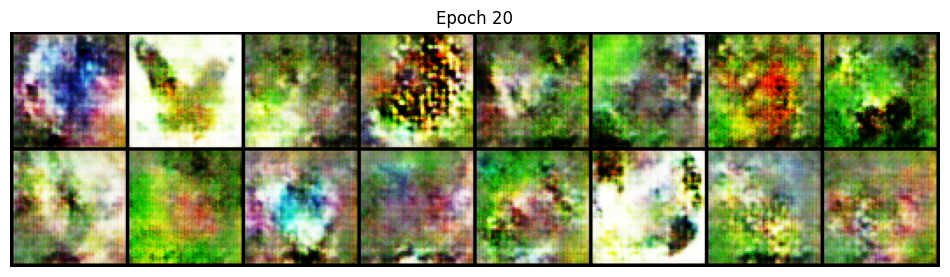

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 20
[21/200][0/57] Loss_D: 0.7807  Loss_G: 5.4774  D(x): 2.5880  D(G(z)): -0.8927/-5.4717
[21/200][50/57] Loss_D: 0.5992  Loss_G: 3.0746  D(x): 1.2756  D(G(z)): -2.2174/-3.0150
[22/200][0/57] Loss_D: 0.8013  Loss_G: 2.2601  D(x): 0.5816  D(G(z)): -1.8753/-2.1260
[22/200][50/57] Loss_D: 1.0407  Loss_G: 2.1305  D(x): -0.4276  D(G(z)): -4.6617/-1.9193
[23/200][0/57] Loss_D: 0.6414  Loss_G: 4.6497  D(x): 2.0915  D(G(z)): -1.9208/-4.6352
[23/200][50/57] Loss_D: 0.7406  Loss_G: 2.7864  D(x): 0.2876  D(G(z)): -4.1385/-2.6853
[24/200][0/57] Loss_D: 0.6065  Loss_G: 4.4472  D(x): 2.4936  D(G(z)): -1.8247/-4.4329
[24/200][50/57] Loss_D: 0.5225  Loss_G: 3.3830  D(x): 1.6249  D(G(z)): -2.6748/-3.3350
[25/200][0/57] Loss_D: 0.8621  Loss_G: 5.1667  D(x): 2.0763  D(G(z)): -0.8985/-5.1572
[25/200

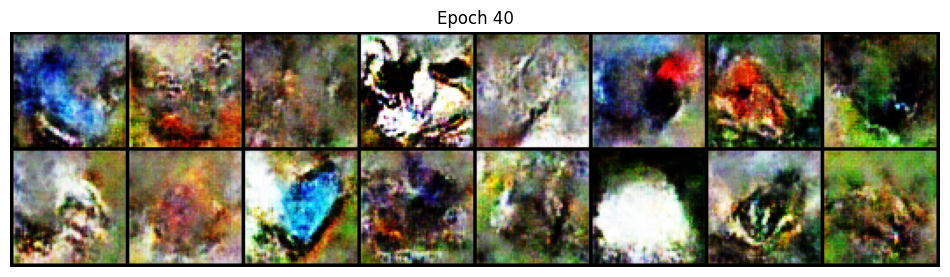

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 40
[41/200][0/57] Loss_D: 0.5180  Loss_G: 3.6414  D(x): 1.8162  D(G(z)): -2.0386/-3.6086
[41/200][50/57] Loss_D: 0.6755  Loss_G: 3.4821  D(x): 1.5483  D(G(z)): -1.4029/-3.4416
[42/200][0/57] Loss_D: 0.5579  Loss_G: 2.3250  D(x): 1.1267  D(G(z)): -2.6808/-2.1863
[42/200][50/57] Loss_D: 0.4547  Loss_G: 3.8226  D(x): 1.6135  D(G(z)): -3.3729/-3.7919
[43/200][0/57] Loss_D: 0.7913  Loss_G: 4.2420  D(x): 3.2538  D(G(z)): -1.3139/-4.2175
[43/200][50/57] Loss_D: 0.5238  Loss_G: 2.9890  D(x): 1.4391  D(G(z)): -2.6364/-2.9286
[44/200][0/57] Loss_D: 0.7321  Loss_G: 2.3761  D(x): 0.3383  D(G(z)): -3.5903/-2.2168
[44/200][50/57] Loss_D: 0.9556  Loss_G: 5.2775  D(x): 3.5179  D(G(z)): -0.6669/-5.2680
[45/200][0/57] Loss_D: 0.5457  Loss_G: 3.1080  D(x): 0.9883  D(G(z)): -3.1783/-3.0419
[45/200]

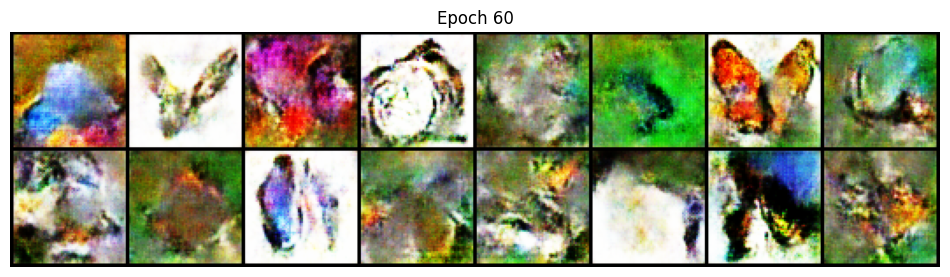

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 60
[61/200][0/57] Loss_D: 0.7910  Loss_G: 4.6736  D(x): 2.8808  D(G(z)): -0.8424/-4.6612
[61/200][50/57] Loss_D: 0.5019  Loss_G: 2.7595  D(x): 1.3161  D(G(z)): -3.0372/-2.6803
[62/200][0/57] Loss_D: 0.6568  Loss_G: 4.6436  D(x): 2.5105  D(G(z)): -1.2347/-4.6324
[62/200][50/57] Loss_D: 0.6028  Loss_G: 2.1646  D(x): 0.9070  D(G(z)): -2.2611/-2.0195
[63/200][0/57] Loss_D: 0.6792  Loss_G: 1.7744  D(x): 0.8277  D(G(z)): -2.6212/-1.5521
[63/200][50/57] Loss_D: 0.6381  Loss_G: 1.9828  D(x): 0.6104  D(G(z)): -3.3265/-1.8153
[64/200][0/57] Loss_D: 0.6710  Loss_G: 4.4671  D(x): 2.9426  D(G(z)): -1.3248/-4.4521
[64/200][50/57] Loss_D: 0.5410  Loss_G: 4.4274  D(x): 2.5968  D(G(z)): -1.6787/-4.4131
[65/200][0/57] Loss_D: 1.0560  Loss_G: 5.9973  D(x): 3.6840  D(G(z)): -0.2696/-5.9942
[65/200]

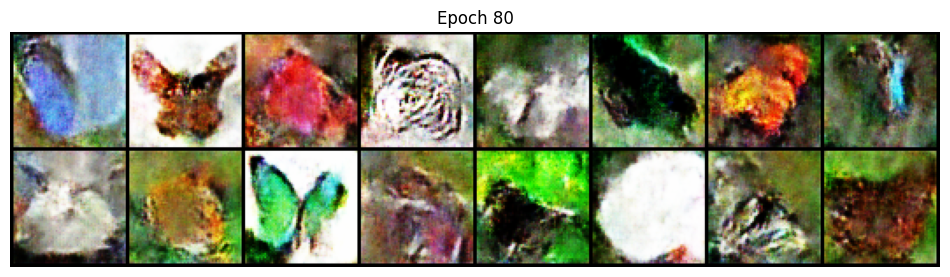

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 80
[81/200][0/57] Loss_D: 0.4931  Loss_G: 3.2001  D(x): 1.9701  D(G(z)): -2.5964/-3.1435
[81/200][50/57] Loss_D: 0.9192  Loss_G: 4.9286  D(x): 2.7610  D(G(z)): -0.4541/-4.9179
[82/200][0/57] Loss_D: 0.5840  Loss_G: 3.3095  D(x): 1.1408  D(G(z)): -2.6849/-3.2502
[82/200][50/57] Loss_D: 0.6473  Loss_G: 2.5365  D(x): 0.6195  D(G(z)): -3.7228/-2.4316
[83/200][0/57] Loss_D: 0.5253  Loss_G: 3.2001  D(x): 1.6009  D(G(z)): -2.4778/-3.1470
[83/200][50/57] Loss_D: 0.5406  Loss_G: 2.3951  D(x): 1.4095  D(G(z)): -2.3610/-2.2789
[84/200][0/57] Loss_D: 0.4577  Loss_G: 3.3883  D(x): 1.6416  D(G(z)): -2.6261/-3.3484
[84/200][50/57] Loss_D: 0.6176  Loss_G: 2.3021  D(x): 0.8925  D(G(z)): -2.9641/-2.1559
[85/200][0/57] Loss_D: 0.7823  Loss_G: 4.2175  D(x): 2.5865  D(G(z)): -0.8631/-4.1970
[85/200]

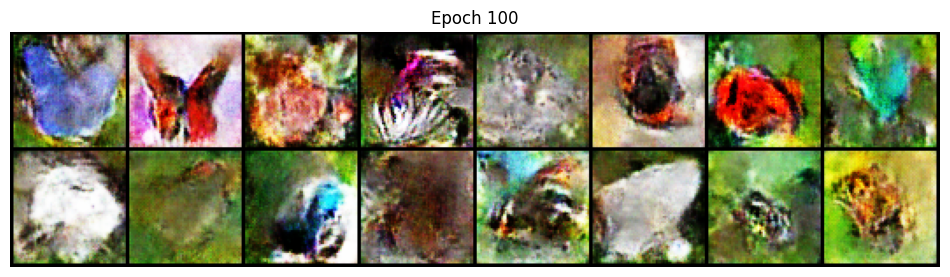

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 100
[101/200][0/57] Loss_D: 0.7284  Loss_G: 3.4459  D(x): 1.9218  D(G(z)): -1.3515/-3.4042
[101/200][50/57] Loss_D: 0.6187  Loss_G: 3.5797  D(x): 2.0577  D(G(z)): -1.4102/-3.5447
[102/200][0/57] Loss_D: 0.6134  Loss_G: 2.6830  D(x): 1.3046  D(G(z)): -2.0810/-2.5938
[102/200][50/57] Loss_D: 0.6322  Loss_G: 3.2301  D(x): 1.2985  D(G(z)): -1.6520/-3.1752
[103/200][0/57] Loss_D: 0.6194  Loss_G: 2.7861  D(x): 1.6225  D(G(z)): -1.7004/-2.7129
[103/200][50/57] Loss_D: 0.5836  Loss_G: 2.9650  D(x): 1.5227  D(G(z)): -1.7616/-2.9078
[104/200][0/57] Loss_D: 0.4544  Loss_G: 2.7634  D(x): 1.6314  D(G(z)): -2.8915/-2.6841
[104/200][50/57] Loss_D: 0.6098  Loss_G: 1.9012  D(x): 0.7233  D(G(z)): -2.9436/-1.7202
[105/200][0/57] Loss_D: 0.6963  Loss_G: 1.2962  D(x): 0.8999  D(G(z)): -2.2370/-0.844

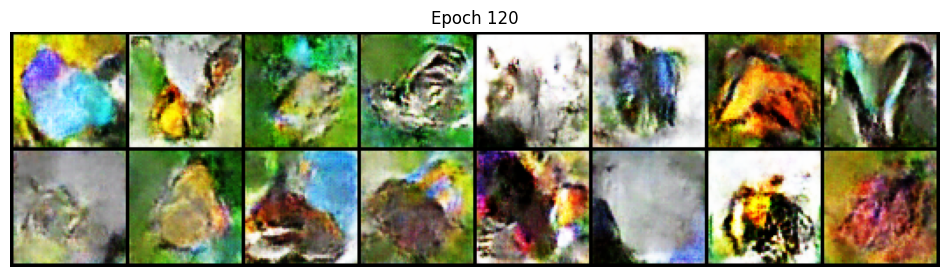

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 120
[121/200][0/57] Loss_D: 0.5293  Loss_G: 2.3445  D(x): 1.0224  D(G(z)): -2.9572/-2.2143
[121/200][50/57] Loss_D: 0.4842  Loss_G: 4.1753  D(x): 1.8466  D(G(z)): -2.5293/-4.1524
[122/200][0/57] Loss_D: 0.6052  Loss_G: 3.5723  D(x): 2.3358  D(G(z)): -1.5944/-3.5342
[122/200][50/57] Loss_D: 0.5722  Loss_G: 2.7028  D(x): 1.4416  D(G(z)): -1.8968/-2.6226
[123/200][0/57] Loss_D: 0.8701  Loss_G: 1.1846  D(x): -0.1269  D(G(z)): -3.0661/-0.7095
[123/200][50/57] Loss_D: 0.5575  Loss_G: 3.3634  D(x): 1.2612  D(G(z)): -2.3506/-3.3164
[124/200][0/57] Loss_D: 0.6625  Loss_G: 2.6780  D(x): 0.8922  D(G(z)): -2.4796/-2.5715
[124/200][50/57] Loss_D: 0.6080  Loss_G: 1.8973  D(x): 0.7470  D(G(z)): -2.8478/-1.7085
[125/200][0/57] Loss_D: 0.5537  Loss_G: 2.7042  D(x): 1.6009  D(G(z)): -2.0301/-2.62

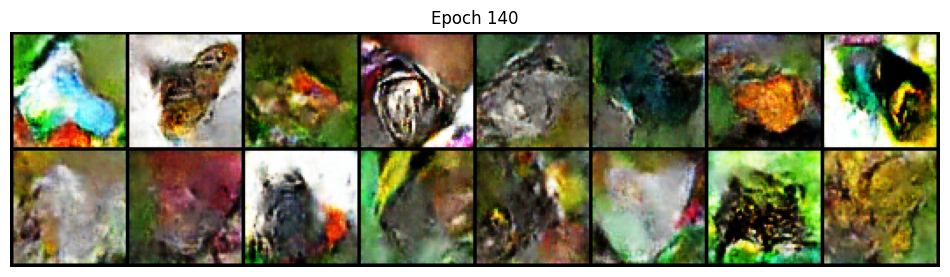

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 140
[141/200][0/57] Loss_D: 1.2556  Loss_G: 5.1534  D(x): 2.7375  D(G(z)): 0.1474/-5.1439
[141/200][50/57] Loss_D: 0.6090  Loss_G: 3.5336  D(x): 1.7366  D(G(z)): -1.5464/-3.4989
[142/200][0/57] Loss_D: 0.8857  Loss_G: 3.9348  D(x): 3.9792  D(G(z)): -1.1534/-3.8885
[142/200][50/57] Loss_D: 0.5999  Loss_G: 2.8267  D(x): 1.6251  D(G(z)): -1.7111/-2.7538
[143/200][0/57] Loss_D: 0.9027  Loss_G: 4.7169  D(x): 2.8997  D(G(z)): -0.6684/-4.7023
[143/200][50/57] Loss_D: 0.5737  Loss_G: 3.6820  D(x): 1.5340  D(G(z)): -2.1559/-3.6496
[144/200][0/57] Loss_D: 0.5269  Loss_G: 3.1977  D(x): 1.1128  D(G(z)): -3.4358/-3.1417
[144/200][50/57] Loss_D: 0.6506  Loss_G: 3.2960  D(x): 2.5372  D(G(z)): -1.2973/-3.2536
[145/200][0/57] Loss_D: 0.4879  Loss_G: 3.4916  D(x): 2.1745  D(G(z)): -2.1984/-3.4530

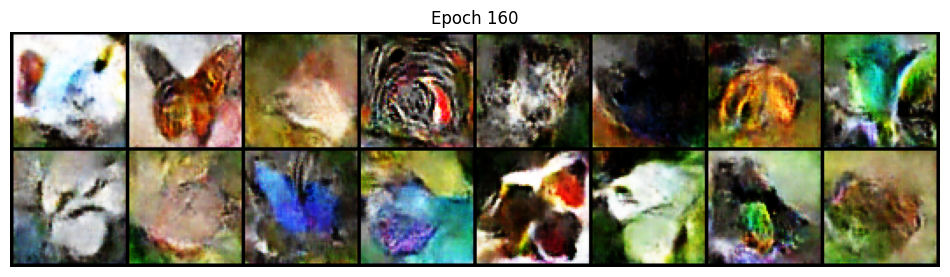

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 160
[161/200][0/57] Loss_D: 0.5331  Loss_G: 3.8744  D(x): 1.3492  D(G(z)): -3.3693/-3.8415
[161/200][50/57] Loss_D: 0.4624  Loss_G: 3.7647  D(x): 1.1365  D(G(z)): -4.4783/-3.7370
[162/200][0/57] Loss_D: 0.4718  Loss_G: 2.9850  D(x): 1.6807  D(G(z)): -2.5995/-2.9219
[162/200][50/57] Loss_D: 0.6985  Loss_G: 3.2794  D(x): 2.4467  D(G(z)): -1.2096/-3.2314
[163/200][0/57] Loss_D: 0.4130  Loss_G: 3.8197  D(x): 2.3768  D(G(z)): -3.0094/-3.7924
[163/200][50/57] Loss_D: 0.6142  Loss_G: 3.5454  D(x): 2.0747  D(G(z)): -1.6252/-3.5098
[164/200][0/57] Loss_D: 0.5492  Loss_G: 3.4739  D(x): 2.0470  D(G(z)): -1.6974/-3.4350
[164/200][50/57] Loss_D: 0.6095  Loss_G: 4.0170  D(x): 2.5658  D(G(z)): -1.5169/-3.9950
[165/200][0/57] Loss_D: 0.4560  Loss_G: 2.9672  D(x): 1.5868  D(G(z)): -3.1056/-2.904

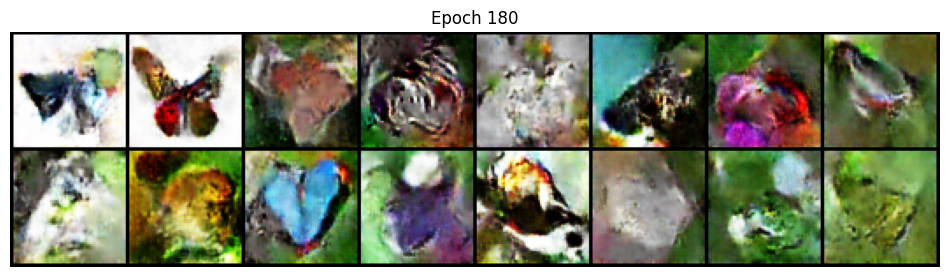

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 180
[181/200][0/57] Loss_D: 0.9510  Loss_G: 4.7693  D(x): 3.4765  D(G(z)): -0.4656/-4.7571
[181/200][50/57] Loss_D: 0.4721  Loss_G: 3.2406  D(x): 1.2955  D(G(z)): -3.1310/-3.1944
[182/200][0/57] Loss_D: 0.8992  Loss_G: 4.1726  D(x): 3.4875  D(G(z)): -0.5741/-4.1503
[182/200][50/57] Loss_D: 0.6731  Loss_G: 4.0373  D(x): 3.1307  D(G(z)): -1.1504/-4.0168
[183/200][0/57] Loss_D: 0.7196  Loss_G: 4.5531  D(x): 3.6176  D(G(z)): -1.1482/-4.5405
[183/200][50/57] Loss_D: 0.4703  Loss_G: 3.4083  D(x): 2.1353  D(G(z)): -2.3159/-3.3691
[184/200][0/57] Loss_D: 0.5717  Loss_G: 4.6227  D(x): 2.6680  D(G(z)): -1.5437/-4.6112
[184/200][50/57] Loss_D: 0.5738  Loss_G: 2.5219  D(x): 1.8958  D(G(z)): -1.5506/-2.4274
[185/200][0/57] Loss_D: 0.7176  Loss_G: 1.6482  D(x): 0.1953  D(G(z)): -3.4585/-1.400

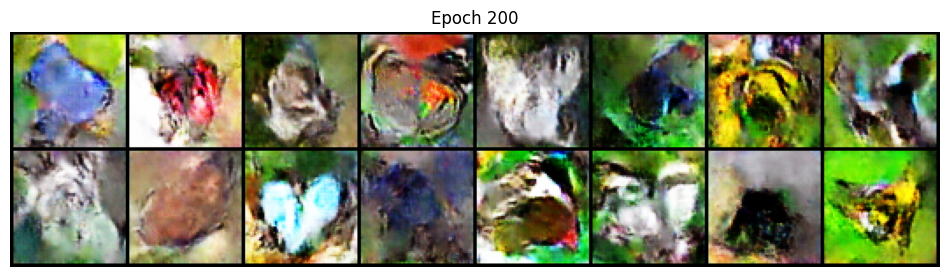

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_discriminator.pth
Checkpoints saved at epoch 200
Training complete.


In [10]:
# ── Training loop — mirrors GAN.py structure closely ──────────────────────
# Variable names and comments intentionally match GAN.py for clarity.

G_losses, D_losses = [], []

for epoch in range(NUM_EPOCHS):
    epoch_G, epoch_D = 0.0, 0.0
    for i, (data, labels) in enumerate(train_loader):

        # ─── Update D: maximise log(D(x)) + log(1 - D(G(z))) ─────────────
        # (mirrors GAN.py comment style verbatim)
        netD.zero_grad()
        real_cpu  = data.to(device)           # real images moved to GPU
        lbl       = labels.to(device)
        batch_size = real_cpu.size(0)

        # Real image pass
        label = torch.full((batch_size,), real_label, dtype=torch.float, device=device)
        output    = netD(real_cpu, lbl)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Fake image pass
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake  = netG(noise, lbl)
        label.fill_(fake_label)
        output    = netD(fake.detach(), lbl)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1    = output.mean().item()
        errD      = errD_real + errD_fake
        optimizerD.step()

        # ─── Update G: maximise log(D(G(z))) ─────────────────────────────
        netG.zero_grad()
        label.fill_(1.0)               # fake labels are real for G cost
        output = netD(fake, lbl)
        errG   = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        epoch_G += errG.item()
        epoch_D += errD.item()

        if i % 50 == 0:
            print(f"[{epoch+1}/{NUM_EPOCHS}][{i}/{len(train_loader)}] "
                  f"Loss_D: {errD.item():.4f}  Loss_G: {errG.item():.4f}  "
                  f"D(x): {D_x:.4f}  D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}")

    G_losses.append(epoch_G / len(train_loader))
    D_losses.append(epoch_D / len(train_loader))

    # ── Save generated samples every SAVE_EVERY epochs (mirrors GAN.py) ──
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        netG.eval()
        with torch.no_grad():
            sample_lbl  = torch.arange(min(16, NUM_CLASSES), device=device)
            noise_fixed = torch.randn(len(sample_lbl), LATENT_DIM, 1, 1, device=device)
            fake_sample = (netG(noise_fixed, sample_lbl).detach().cpu() + 1) * 0.5
        grid = make_grid(fake_sample, nrow=8, padding=2)
        plt.figure(figsize=(12, 6))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis("off")
        plt.title(f"Epoch {epoch+1}")
        plt.show()
        netG.train()

        save_checkpoint(netG, NETG_PATH, epoch=epoch + 1)
        save_checkpoint(netD, NETD_PATH, epoch=epoch + 1)
        print(f"Checkpoints saved at epoch {epoch+1}")

print("Training complete.")

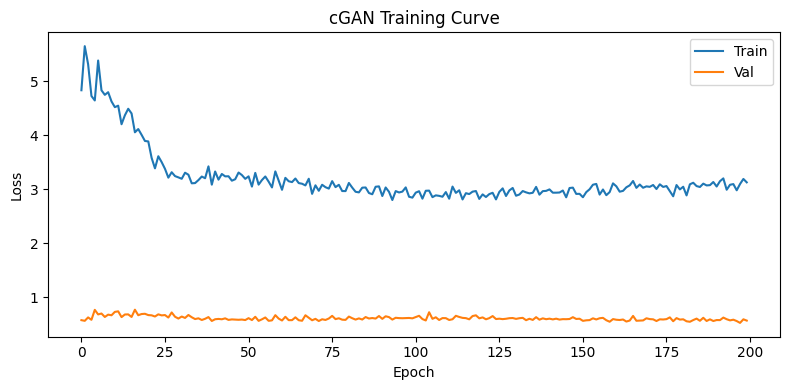

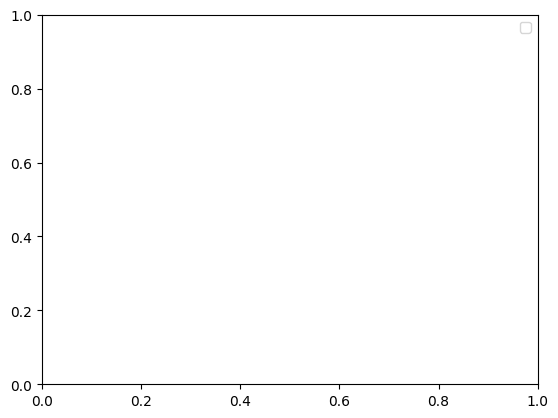

In [11]:
# ── Plot Generator and Discriminator loss curves ──────────────────────────
plot_losses(G_losses, D_losses, ylabel="Loss",
            title="cGAN Training Curve")
plt.legend(["Generator", "Discriminator"])
plt.show()

In [12]:
# ── Generate images per class to balance the dataset ──────────────────────
load_checkpoint(NETG_PATH, netG, device)
netG = netG.to(device)
netG.eval()

class_counts = Counter(train_df["label"].tolist())
TARGET_PER_CLASS = max(class_counts.values())

generated_records = []
with torch.no_grad():
    for class_name, class_idx in label_to_idx.items():
        existing = class_counts.get(class_name, 0)
        n_gen = max(0, TARGET_PER_CLASS - existing)
        if n_gen == 0:
            continue

        all_gen = []
        remaining = n_gen
        while remaining > 0:
            batch_n = min(remaining, BATCH_SIZE)
            noise = torch.randn(batch_n, LATENT_DIM, 1, 1, device=device)
            lbl   = torch.full((batch_n,), class_idx, dtype=torch.long, device=device)
            gen   = netG(noise, lbl).cpu()        # (batch_n, 3, 64, 64) in [-1,1]
            all_gen.append(gen)
            remaining -= batch_n

        gen_imgs = torch.cat(all_gen, dim=0)      # (n_gen, 3, 64, 64)
        gen_imgs = (gen_imgs * 0.5 + 0.5).clamp(0, 1)   # → [0,1]

        for j, img_t in enumerate(gen_imgs):
            fname = f"gan_{class_idx:03d}_{j:04d}.jpg"
            tensor_to_pil(img_t).save(os.path.join(SAVE_DIR, fname))
            generated_records.append({
                "filename": fname,
                "label": class_name,
                "img_dir": SAVE_DIR,
            })

        print(f"  [{class_idx:02d}] {class_name}: generated {n_gen}")

gen_df = pd.DataFrame(generated_records)
gen_df.to_csv(os.path.join(SAVE_DIR, "generated.csv"), index=False)
print(f"\nTotal generated: {len(gen_df):,}  |  CSV saved.")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\gan_generator.pth
  [00] ADONIS: generated 24
  [01] AFRICAN GIANT SWALLOWTAIL: generated 31
  [02] AMERICAN SNOOT: generated 32
  [03] AN 88: generated 26
  [04] APPOLLO: generated 23
  [05] ATALA: generated 17
  [06] BANDED ORANGE HELICONIAN: generated 20
  [07] BANDED PEACOCK: generated 27
  [08] BECKERS WHITE: generated 28
  [09] BLACK HAIRSTREAK: generated 26
  [10] BLUE MORPHO: generated 31
  [11] BLUE SPOTTED CROW: generated 25
  [12] BROWN SIPROETA: generated 18
  [13] CABBAGE WHITE: generated 23
  [14] CAIRNS BIRDWING: generated 27
  [15] CHECQUERED SKIPPER: generated 20
  [16] CHESTNUT: generated 26
  [17] CLEOPATRA: generated 22
  [18] CLODIUS PARNASSIAN: generated 24
  [19] CLOUDED SULPHUR: generated 22
  [20] COMMON BANDED AWL: generated 24
  [21] COMMON WOOD-NYMPH: generated 23
  [22] COPPER TAIL: generated 21
  [23] CRECENT: generated 20
  [24] CRIMSON PATCH: generated 33
  [25] DANAID EGGFLY: gener

## Evaluation of Generative Quality

FID and IS computed globally (all classes) — same protocol as the cVAE notebook.
SSIM is omitted for GANs (outputs are not reconstruction-paired with real images).


In [13]:
def collect_tensor(loader):
    batches = [imgs for imgs, _ in loader]
    return torch.cat(batches, dim=0)

print("Collecting real images…")
real_imgs = collect_tensor(train_loader)

print("Collecting GAN-generated images…")
gen_set  = ButterflyDataset(gen_df, SAVE_DIR, label_to_idx,
                             transform=get_eval_transform(IMAGE_SIZE))
gen_dl   = make_dataloader(gen_set, BATCH_SIZE, shuffle=False)
gen_imgs = collect_tensor(gen_dl)

print(f"Real: {real_imgs.shape}  |  Generated: {gen_imgs.shape}")

Real: torch.Size([3606, 3, 64, 64])  |  Generated: torch.Size([1869, 3, 64, 64])


In [14]:
print("Computing FID…")
fid_score = compute_fid(real_imgs, gen_imgs, device=device)
print(f"FID: {fid_score:.2f}  (lower is better)")

print("Computing IS…")
is_mean, is_std = compute_inception_score(gen_imgs, device=device)
print(f"IS:  {is_mean:.3f} ± {is_std:.3f}  (higher is better)")

print("\n=== cGAN Generative Quality Summary ===")
print(f"  FID : {fid_score:.2f}")
print(f"  IS  : {is_mean:.3f} ± {is_std:.3f}")

Computing FID…
FID: 209.75  (lower is better)
Computing IS…
IS:  2.439 ± 0.351  (higher is better)

=== cGAN Generative Quality Summary ===
  FID : 209.75
  IS  : 2.439 ± 0.351
